In [406]:
from datetime import datetime, timedelta
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd
import ta
import seaborn as sns
import yfinance as yf
import os

## Download Data

In [407]:
def download_data(ticker : str, start_date : datetime, end_date : datetime, interval : str, path : str) -> None:
    df = yf.download(ticker, 
                     start=start_date, 
                     end=end_date, 
                     interval=interval, 
                     auto_adjust=True, 
                     keepna=False, 
                     multi_level_index=False)

    df.to_csv(os.path.join(path,f"{ticker}.csv"))
    return df

In [408]:
directory_path = os.getcwd()
data_path = os.path.join(directory_path, "data/")

if not os.path.exists(data_path):
    os.mkdir(data_path)  

ticker = "JPM" # JP Morgan

end_date = datetime.today()
start_date = end_date - timedelta(days=365*20) # Max days for 5 minutes interval is 60 days

interval = '1d'

if not os.path.exists(os.path.join(data_path,f"{ticker}.csv")):
    df = download_data(ticker=ticker, start_date=start_date, end_date=end_date, interval=interval, path=data_path)
else :
    df = pd.read_csv(os.path.join(data_path,f"{ticker}.csv"), index_col=0, parse_dates=True)

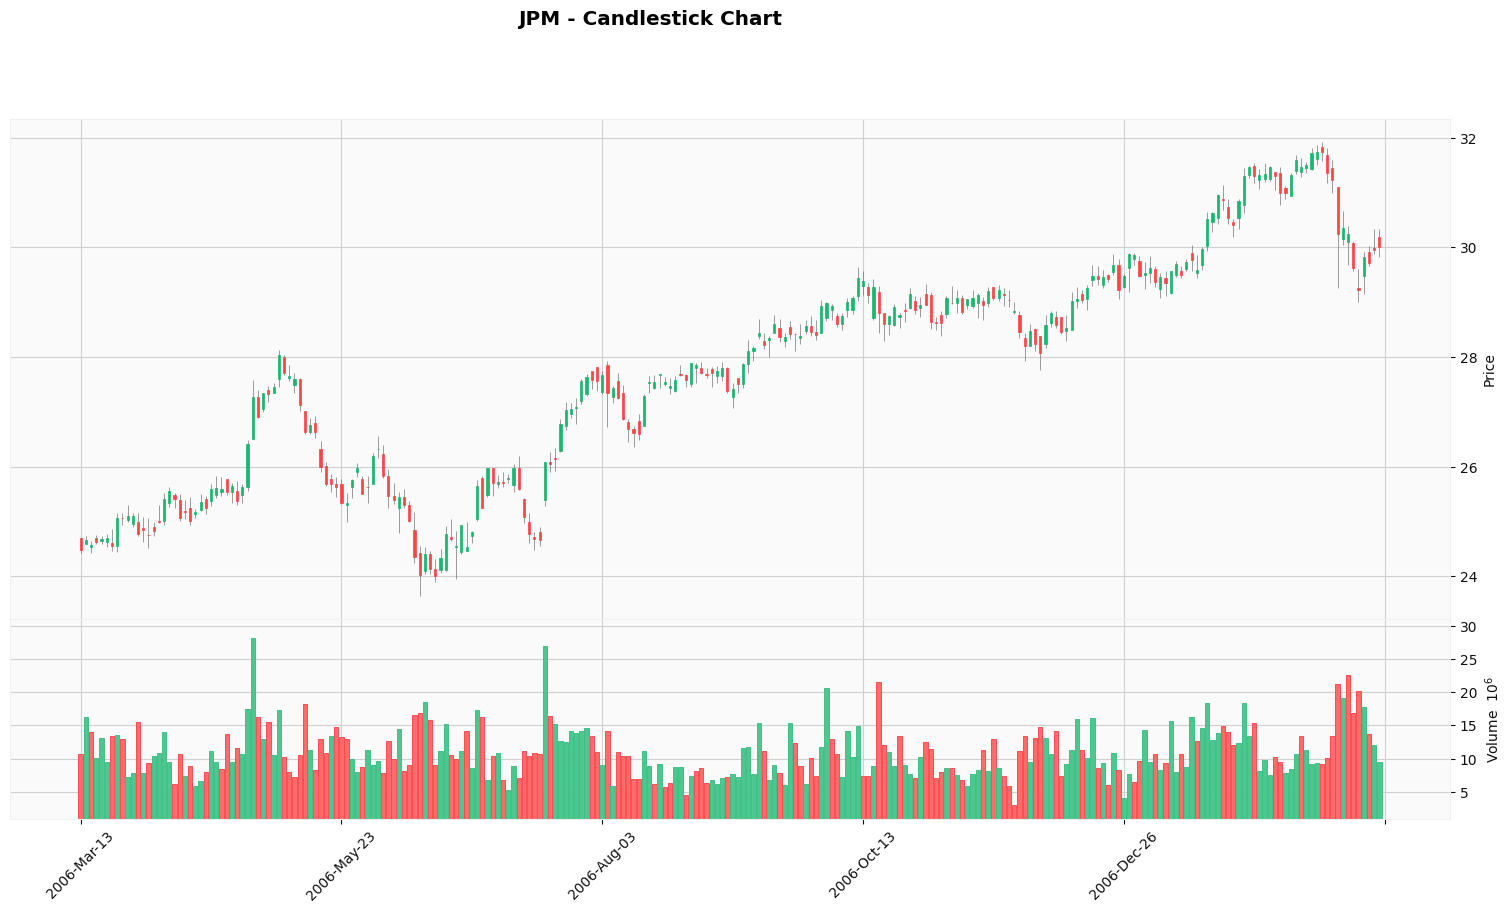

In [409]:
import mplfinance as mpf

mpf.plot(
    df.head(250),
    type="candle",
    style="yahoo",
    figsize=(20, 10),
    volume=True,
    title=f"{ticker} - Candlestick Chart"
)

## Feature enginerring

In [410]:
def feature_enginerring(dataframe : pd.DataFrame):

    df = dataframe.copy()

    # Price-based features
    df["price_change"] = df['Close'].pct_change()
    df["high_low_ratio"] = df['High']/df['Low']
    df["open_close_ratio"] = df['Close']/df['Open']
    df["body_size"] = abs(df['Close'] - df['Open'])

    # Technical indicators (TA-Lib)
    df['rsi'] = ta.momentum.StochRSIIndicator(df['Close'], window=14).stochrsi()
    df['macd'] = ta.trend.MACD(df['Close']).macd()
    df['macd_signal'] = ta.trend.MACD(df['Close']).macd_signal()
    df['bb_upper'] = ta.volatility.BollingerBands(df['Close']).bollinger_hband()
    df['bb_lower'] = ta.volatility.BollingerBands(df['Close']).bollinger_lband()
    df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['Close']

    # Volume features
    df['volume_sma'] = df['Volume'].rolling(20).mean()
    df['volume_ratio'] = df['Volume'] / df['volume_sma']
    
    # Lag indicators usefull for small timeframes to have a better overview
    for lag in [1, 3, 6, 12]:  # 5m, 15m, 30m, 1h lags
        df[f'price_lag_{lag}'] = df['Close'].pct_change(lag)
        df[f'rsi_lag_{lag}'] = df['rsi'].shift(lag)
        df[f'volume_lag_{lag}'] = df['Volume'].shift(lag)
    
    # Volatility
    df['volatility'] = df['price_change'].rolling(20).std()
    df['atr'] = ta.volatility.AverageTrueRange(df['High'], df['Low'], df['Close']).average_true_range()
    df['vix_proxy'] = df['Close'].pct_change().rolling(20).std() * np.sqrt(252)

    # Time features
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['is_opening_hour'] = (df['hour'] <= 10).astype(int)  # 9h30-10h US ( as we have a US stock )
    df['is_closing_hour'] = (df['hour'] >= 15).astype(int)

    # Market direction 
    future_return = df['Close'].pct_change(5).shift(-5)
    df['target']  = (future_return > 0.01).astype(int)


    df = df.drop(columns=['Close', 'High', 'Low', 'Open', 'Volume', 'volume_sma'])

    return df.dropna()

In [411]:
dataset_path = os.path.join(data_path,"dataset")

if not os.path.exists(dataset_path):
    os.mkdir(dataset_path)

if not os.path.exists(os.path.join(dataset_path,'train')):
    os.mkdir(os.path.join(dataset_path,'train'))

if not os.path.exists(os.path.join(dataset_path,'test')):
    os.mkdir(os.path.join(os.path.join(dataset_path,'test')))

In [412]:
split    = int(len(df) * 0.8)
df_train = df.iloc[:split].copy()
df_test  = df.iloc[split:].copy()

close_test = df_test['Close'].copy()

X_train_featured = feature_enginerring(df_train)
X_test_featured  = feature_enginerring(df_test)

y_train = X_train_featured['target']
X_train = X_train_featured.drop('target', axis=1)

y_test  = X_test_featured['target']
X_test  = X_test_featured.drop('target', axis=1)

close_test = close_test.loc[X_test.index]

print("Train :", X_train.index[0], "→", X_train.index[-1])
print("Test  :", X_test.index[0],  "→", X_test.index[-1])

dart_params = {
    'booster'          : 'dart',
    'objective'        : 'binary:logistic',
    'eval_metric'      : 'auc',
    'max_depth'        : 3,       
    'min_child_weight' : 20,       
    'gamma'            : 0.2,
    'learning_rate'    : 0.005,    
    'n_estimators'     : 1000,
    'sample_type'      : 'uniform',
    'normalize_type'   : 'tree',
    'rate_drop'        : 0.15,
    'skip_drop'        : 0.4,
    'subsample'        : 0.6,
    'colsample_bytree' : 0.6,
    'colsample_bylevel': 0.6,
    'scale_pos_weight' : 2,
    'seed'             : 42
}

model = xgb.XGBClassifier(**dart_params)
model.fit(X_train, y_train)

Train : 2006-05-05 00:00:00 → 2022-03-01 00:00:00
Test  : 2022-04-26 00:00:00 → 2026-03-05 00:00:00


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,'dart'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,0.6
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 